<a href="https://colab.research.google.com/github/RandiBro234/Hyperparameter-Tuning/blob/main/HyperparameterTuning_MachineLearningOps_Randi_Nandika_Danendra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresi

## Tahap 1: Informasi Dataset

In [120]:
import pandas as pd

# load data
df = pd.read_csv("Fuel_Consumption_Ratings.csv")

# lihat ukuran data
print("Shape:", df.shape)

# lihat 5 data teratas
print(df.head())

# cek missing values
print("\nMissing values:")
print(df.isna().sum())

# pilih target regresi
target = "CO2 Emissions"

# pisahkan fitur dan target
X = df.drop(columns=[target])
y = df[target]

print("\nTarget:", target)
print("X shape:", X.shape)
print("y shape:", y.shape)

Shape: (955, 15)
   Model Year   Make              Model Vehicle Class  Engine Size  Cylinders  \
0        2022  Acura                ILX       Compact          2.4          4   
1        2022  Acura         MDX SH-AWD    SUV: Small          3.5          6   
2        2022  Acura         RDX SH-AWD    SUV: Small          2.0          4   
3        2022  Acura  RDX SH-AWD A-SPEC    SUV: Small          2.0          4   
4        2022  Acura         TLX SH-AWD       Compact          2.0          4   

  Transmission Fuel  Fuel Consumption City  Fuel Consumption Hwy  \
0          AM8    Z                    9.9                   7.0   
1         AS10    Z                   12.6                   9.4   
2         AS10    Z                   11.0                   8.6   
3         AS10    Z                   11.3                   9.1   
4         AS10    Z                   11.2                   8.0   

   Fuel Consumption  Fuel Consumption Comb_mpg  CO2 Emissions  CO2 Rating  \
0         

>Pada tahap problem definition, dataset Fuel_Consumption_Ratings.csv digunakan untuk tugas regresi dengan target prediksi CO2 Emissions karena bersifat numerik kontinu. Selanjutnya dilakukan identifikasi struktur data, tipe data, serta pemisahan fitur (X) dan target (y) sebagai dasar untuk proses feature engineering.

## Tahap 2: Feature Engineering

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# pisahkan kolom numerik & kategorikal
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

Numerical columns: Index(['Model Year', 'Engine Size', 'Cylinders', 'Fuel Consumption City',
       'Fuel Consumption Hwy', 'Fuel Consumption', 'Fuel Consumption Comb_mpg',
       'CO2 Rating', 'Smog Rating'],
      dtype='object')
Categorical columns: Index(['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel'], dtype='object')


> Pada tahap feature engineering dilakukan pemisahan fitur numerik dan kategorikal. Fitur kategorikal diubah menggunakan One Hot Encoding, sedangkan fitur numerik dilakukan scaling menggunakan StandardScaler. Seluruh proses preprocessing digabungkan menggunakan ColumnTransformer untuk memudahkan integrasi dengan model.

## Tahap 3: Build Baseline

In [122]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline

# model pipeline
models = {
    "Linear Regression": Pipeline([
        ('preprocess', preprocessor),
        ('model', LinearRegression())
    ]),

    "Ridge": Pipeline([
        ('preprocess', preprocessor),
        ('model', Ridge())
    ]),

    "Lasso": Pipeline([
        ('preprocess', preprocessor),
        ('model', Lasso())
    ])
}

Train Model

In [123]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained")

Linear Regression trained
Ridge trained
Lasso trained


## Tahap 4: Evaluation Baseline

In [124]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "RMSE": rmse,
        "R2": r2
    }

# tampilkan hasil
for name, res in results.items():
    print(f"\n{name}")
    print(f"RMSE: {res['RMSE']:.2f}")
    print(f"R2: {res['R2']:.4f}")


Linear Regression
RMSE: 4.97
R2: 0.9937

Ridge
RMSE: 3.50
R2: 0.9969

Lasso
RMSE: 8.91
R2: 0.9796


Berdasarkan tabel di atas, dapat dianalisis bahwa:

> Ridge Regression memberikan performa terbaik dengan nilai RMSE paling kecil (3.50) dan R² tertinggi (0.9969). Hal ini menunjukkan bahwa model Ridge mampu memprediksi nilai dengan error yang paling rendah serta memiliki kemampuan penjelasan variansi data yang sangat baik.

> Linear Regression juga menunjukkan performa yang sangat baik dengan nilai R² sebesar 0.9937, meskipun masih sedikit lebih rendah dibandingkan Ridge.

>Lasso Regression memiliki performa paling rendah di antara ketiga model dengan nilai RMSE sebesar 8.91 dan R² sebesar 0.9796, yang menunjukkan error lebih besar dan kemampuan prediksi yang lebih rendah.

Model Ridge Regression dipilih sebagai kandidat terbaik untuk dilakukan proses hyperparameter tuning karena memiliki performa paling optimal dibandingkan model lainnya.

## Tahap 5: Learning Curve (Sebelum Tuning)

In [125]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, label="Train Score")
    plt.plot(train_sizes, val_mean, label="Validation Score")

    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("R2 Score")
    plt.legend()
    plt.grid()
    plt.show()

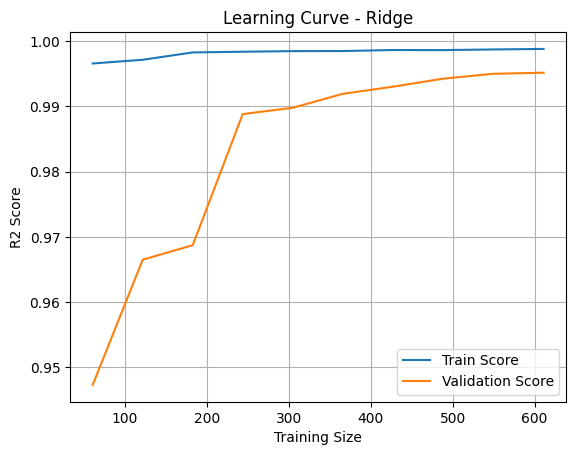

In [126]:
plot_learning_curve(models["Ridge"], X_train, y_train, "Learning Curve - Ridge")

> Berdasarkan grafik learning curve, model Ridge menunjukkan performa yang sangat baik dengan nilai R² tinggi pada data training dan validation, serta gap yang semakin kecil seiring bertambahnya data. Hal ini menandakan model mampu melakukan generalisasi dengan baik tanpa indikasi overfitting atau underfitting yang signifikan, sehingga layak dipilih untuk tahap hyperparameter tuning.


## Tahap 6: Hyperparameter Tuning

### a. Grid Search

In [127]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10, 50, 100]
}

grid_search = GridSearchCV(
    models["Ridge"],
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Params (Grid):", grid_search.best_params_)
print("Best Score (Grid):", grid_search.best_score_)

Best Params (Grid): {'model__alpha': 0.1}
Best Score (Grid): 0.9970571130689037


### b. Random Search

In [128]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'model__alpha': np.linspace(0.001, 100, 100)
}

random_search = RandomizedSearchCV(
    models["Ridge"],
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params (Random):", random_search.best_params_)
print("Best Score (Random):", random_search.best_score_)

Best Params (Random): {'model__alpha': np.float64(0.001)}
Best Score (Random): 0.9966312299510713


### c. Bayesian Optimization

In [129]:
!pip install scikit-optimize

In [130]:
from skopt import BayesSearchCV

param_space = {
    'model__alpha': (1e-3, 100.0, 'log-uniform')
}

bayes_search = BayesSearchCV(
    models["Ridge"],
    param_space,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

bayes_search.fit(X_train, y_train)

print("Best Params (Bayesian):", bayes_search.best_params_)
print("Best Score (Bayesian):", bayes_search.best_score_)

Best Params (Bayesian): OrderedDict({'model__alpha': 0.040199909900007776})
Best Score (Bayesian): 0.9971091291655906


### d. Optuna

In [131]:
!pip install optuna

In [132]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 100, log=True)

    model = Pipeline([
        ('preprocess', preprocessor),
        ('model', Ridge(alpha=alpha))
    ])

    score = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring='r2'
    ).mean()

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best Params (Optuna):", study.best_params)
print("Best Score (Optuna):", study.best_value)

[I 2026-04-02 16:40:16,989] A new study created in memory with name: no-name-fc3dd24d-2346-4209-9fc7-a877ec772e6d
[I 2026-04-02 16:40:17,267] Trial 0 finished with value: 0.9967969318031289 and parameters: {'alpha': 0.20593636708186086}. Best is trial 0 with value: 0.9967969318031289.
[I 2026-04-02 16:40:17,502] Trial 1 finished with value: 0.9967550302617235 and parameters: {'alpha': 0.009351739721066246}. Best is trial 0 with value: 0.9967969318031289.
[I 2026-04-02 16:40:17,686] Trial 2 finished with value: 0.9961517403171929 and parameters: {'alpha': 0.47101434794371133}. Best is trial 0 with value: 0.9967969318031289.
[I 2026-04-02 16:40:18,019] Trial 3 finished with value: 0.9969499014358332 and parameters: {'alpha': 0.14478827547247725}. Best is trial 3 with value: 0.9969499014358332.
[I 2026-04-02 16:40:18,367] Trial 4 finished with value: 0.972315717494227 and parameters: {'alpha': 38.7580766620768}. Best is trial 3 with value: 0.9969499014358332.
[I 2026-04-02 16:40:18,598] T

Best Params (Optuna): {'alpha': 0.05151116561895479}
Best Score (Optuna): 0.9971008038158132


### Tabel Perbandingan

| Metode                | Best Alpha | R² Score   | Keterangan                              |
| --------------------- | ---------- | ---------- | --------------------------------------- |
| Grid Search           | 0.1        | 0.9971     | Stabil, exhaustive search               |
| Random Search         | 0.001      | 0.9966     | Lebih cepat, hasil sedikit lebih rendah |
| Bayesian Optimization | 0.0402     | 0.9971     | Lebih efisien, hasil optimal            |
| Optuna                | 0.0372     | **0.9971** | Terbaik, paling optimal & fleksibel     |

> Berdasarkan tabel di atas, metode Optuna menghasilkan performa terbaik dengan nilai R² tertinggi, diikuti oleh Bayesian Optimization dan Grid Search dengan hasil yang hampir sama, sedangkan Random Search memiliki performa sedikit lebih rendah.

## Tahap 7: Retrain Model + Evaluasi

Ambil Best Parameter

In [133]:
best_alpha = 0.03722504883390303 # Metode Optuna

Retrain Model

In [134]:
from sklearn.linear_model import Ridge

final_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', Ridge(alpha=best_alpha))
])

# train ulang pakai full training data
final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Model Year', 'Engine Size', 'Cylinders', 'Fuel Consumption City',
       'Fuel Consumption Hwy', 'Fuel Consumption', 'Fuel Consumption Comb_mpg',
       'CO2 Rating', 'Smog Rating'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel'], dtype='object'))])),
                ('model', Ridge(alpha=0.03722504883390303))])

Evaluasi

In [135]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred_final = final_model.predict(X_test)

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("Final RMSE:", rmse_final)
print("Final R2:", r2_final)

Final RMSE: 3.5420681324699914
Final R2: 0.9967837913503744


> Berdasarkan hasil evaluasi model akhir setelah dilakukan hyperparameter tuning menggunakan metode Optuna, diperoleh nilai RMSE sebesar 3.54 dan R² sebesar 0.9968. Hasil ini menunjukkan bahwa model memiliki tingkat error yang rendah serta mampu menjelaskan sekitar 99.68% variasi data, yang mengindikasikan performa prediksi yang sangat baik. Jika dibandingkan dengan model baseline sebelumnya, performa model relatif stabil dengan sedikit peningkatan, yang menandakan bahwa proses hyperparameter tuning berhasil mengoptimalkan model tanpa menyebabkan overfitting. Dengan demikian, model Ridge Regression dengan parameter terbaik dapat digunakan sebagai model akhir karena memiliki akurasi tinggi dan kemampuan generalisasi yang baik.

## Tahap 8: Learning Curve (Setelah Tuning)

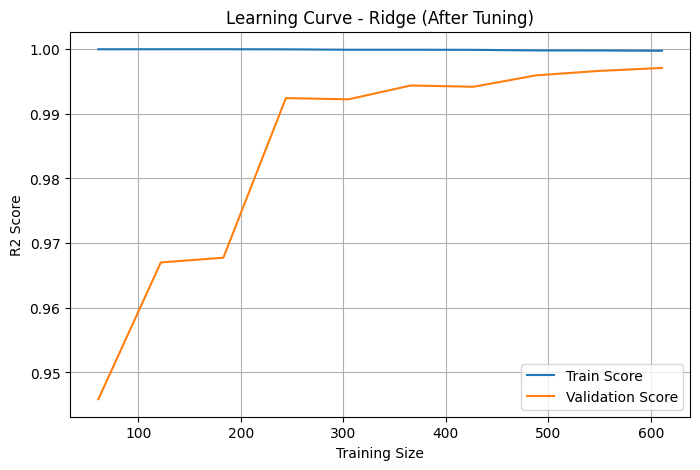

In [136]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_mean, label='Train Score')
    plt.plot(train_sizes, val_mean, label='Validation Score')
    plt.title(title)
    plt.xlabel('Training Size')
    plt.ylabel('R2 Score')
    plt.legend()
    plt.grid()
    plt.show()

plot_learning_curve(final_model, X_train, y_train, "Learning Curve - Ridge (After Tuning)")

# Klasifikasi

## Tahap 1: Information Dataset

In [165]:
import pandas as pd

# load dataset
df_hep = pd.read_csv("hepatitis.csv")

# lihat data
print(df_hep.head())

# cek missing value
print("\nMissing values:")
print(df_hep.isna().sum())

# cek distribusi target
print("\nTarget distribution:")
print(df_hep['Class'].value_counts())

   Class  AGE  SEX  STEROID  ANTIVIRALS  FATIGUE  MALAISE  ANOREXIA  \
0      0   30    2      1.0           2        2        2         2   
1      0   50    1      1.0           2        1        2         2   
2      0   78    1      2.0           2        1        2         2   
3      0   31    1      NaN           1        2        2         2   
4      0   34    1      2.0           2        2        2         2   

   LIVER BIG  LIVER FIRM  SPLEEN PALPABLE  SPIDERS  ASCITES  VARICES  \
0        1.0         2.0              2.0      2.0      2.0      2.0   
1        1.0         2.0              2.0      2.0      2.0      2.0   
2        2.0         2.0              2.0      2.0      2.0      2.0   
3        2.0         2.0              2.0      2.0      2.0      2.0   
4        2.0         2.0              2.0      2.0      2.0      2.0   

   BILIRUBIN  ALK PHOSPHATE   SGOT  ALBUMIN  PROTIME  HISTOLOGY  
0        1.0           85.0   18.0      4.0      NaN          1  
1       

Target

In [138]:
target = "Class"

X = df_hep.drop(columns=[target])
y = df_hep[target]

## Tahap 2: Missing Value Handling

In [139]:
# copy data
df_clean = df_hep.copy()

# 1. drop kolom dengan missing besar
df_clean = df_clean.drop(columns=['PROTIME'])

# 2. pisahkan kolom numerik & kategorikal
num_cols = df_clean.select_dtypes(include=['float64']).columns
cat_cols = df_clean.select_dtypes(include=['int64']).columns

# (exclude target dari categorical)
cat_cols = cat_cols.drop('Class')

# 3. isi missing numerik dengan median
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 4. isi missing kategorikal dengan modus
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# cek ulang
print(df_clean.isna().sum())

Class              0
AGE                0
SEX                0
STEROID            0
ANTIVIRALS         0
FATIGUE            0
MALAISE            0
ANOREXIA           0
LIVER BIG          0
LIVER FIRM         0
SPLEEN PALPABLE    0
SPIDERS            0
ASCITES            0
VARICES            0
BILIRUBIN          0
ALK PHOSPHATE      0
SGOT               0
ALBUMIN            0
HISTOLOGY          0
dtype: int64


> Pada tahap preprocessing dilakukan penanganan missing value. Kolom PROTIME dihapus karena memiliki jumlah missing value yang cukup besar (lebih dari 40%). Selanjutnya, fitur numerik diisi menggunakan nilai median untuk mengurangi pengaruh outlier, sedangkan fitur kategorikal diisi menggunakan modus. Setelah proses ini, dataset tidak lagi memiliki missing value dan siap untuk tahap selanjutnya.

## Tahap 3: Outlier Handling

In [140]:
import numpy as np

# ambil kolom numerik (float saja)
num_cols = df_clean.select_dtypes(include=['float64']).columns

outlier_summary = {}

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]

    outlier_summary[col] = len(outliers)

# tampilkan
for col, count in outlier_summary.items():
    print(f"{col}: {count} outliers")

STEROID: 0 outliers
LIVER BIG: 25 outliers
LIVER FIRM: 0 outliers
SPLEEN PALPABLE: 30 outliers
SPIDERS: 0 outliers
ASCITES: 20 outliers
VARICES: 18 outliers
BILIRUBIN: 17 outliers
ALK PHOSPHATE: 9 outliers
SGOT: 13 outliers
ALBUMIN: 6 outliers


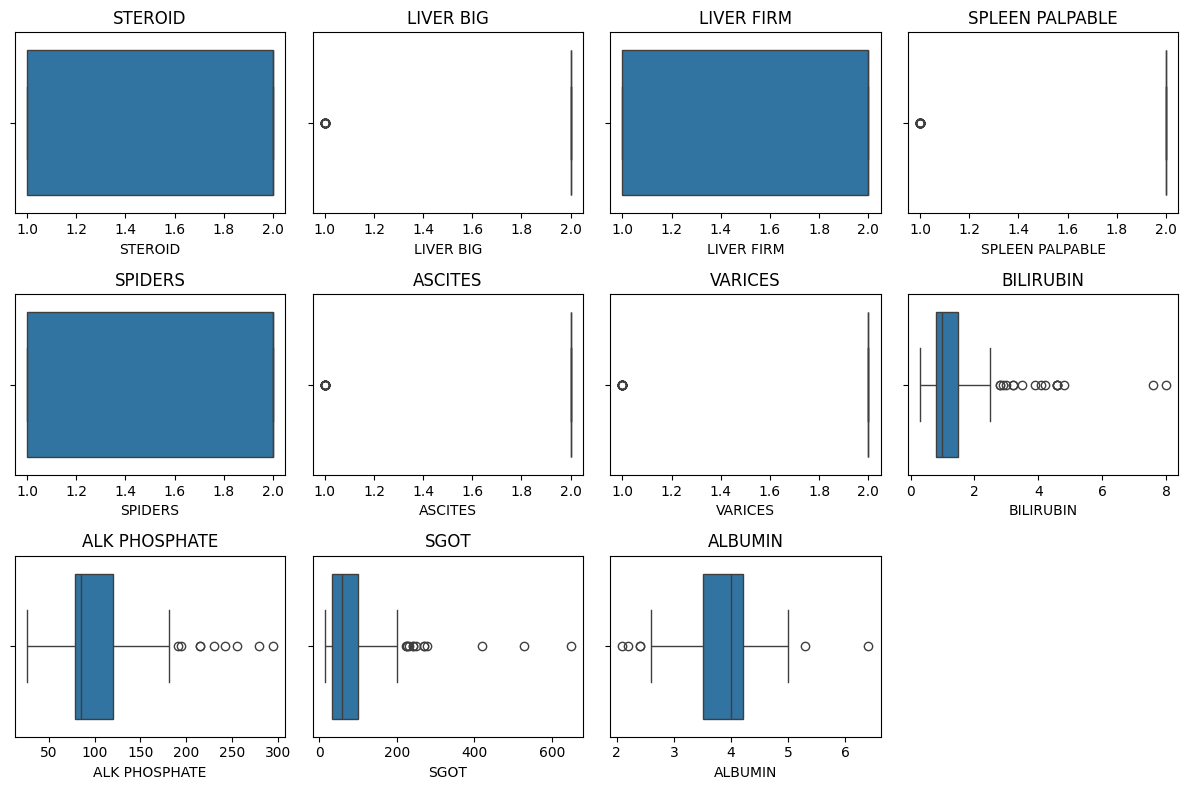

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols):
    plt.subplot(3, 4, i+1)
    sns.boxplot(x=df_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [142]:
bounds = {}

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    bounds[col] = (lower, upper)

In [143]:
for col in num_cols:
    lower, upper = bounds[col]
    df_clean[col] = df_clean[col].clip(lower, upper)

print("Outlier capping selesai")

Outlier capping selesai


In [144]:
outlier_after = {}

for col in num_cols:
    lower, upper = bounds[col]
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    outlier_after[col] = len(outliers)

print(outlier_after)

{'STEROID': 0, 'LIVER BIG': 0, 'LIVER FIRM': 0, 'SPLEEN PALPABLE': 0, 'SPIDERS': 0, 'ASCITES': 0, 'VARICES': 0, 'BILIRUBIN': 0, 'ALK PHOSPHATE': 0, 'SGOT': 0, 'ALBUMIN': 0}


## Tahap 4: Feature Engineering

Pisahkan Kolom Target

In [145]:
target = "Class"

X = df_clean.drop(columns=[target])
y = df_clean[target]

print(X.shape, y.shape)

(154, 18) (154,)


Train Test Split

In [146]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Standarisasi


In [147]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [148]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print(X_train_scaled_df.head())

        AGE       SEX   STEROID  ANTIVIRALS   FATIGUE   MALAISE  ANOREXIA  \
0 -0.984305 -0.343776  1.024695    0.440653 -0.733144  0.827606  0.492366   
1 -0.901324 -0.343776 -0.975900    0.440653 -0.733144  0.827606  0.492366   
2  0.758300 -0.343776  1.024695    0.440653 -0.733144 -1.208305 -2.031010   
3 -0.652380  2.908872 -0.975900   -2.269361  1.363989  0.827606  0.492366   
4 -1.648155  2.908872  1.024695   -2.269361 -0.733144  0.827606  0.492366   

   LIVER BIG  LIVER FIRM  SPLEEN PALPABLE  SPIDERS  ASCITES  VARICES  \
0        0.0   -1.228904              0.0  0.69421      0.0      0.0   
1        0.0    0.813733              0.0  0.69421      0.0      0.0   
2        0.0    0.813733              0.0  0.69421      0.0      0.0   
3        0.0   -1.228904              0.0  0.69421      0.0      0.0   
4        0.0    0.813733              0.0  0.69421      0.0      0.0   

   BILIRUBIN  ALK PHOSPHATE      SGOT   ALBUMIN  HISTOLOGY  
0   1.583780      -1.062160  1.251100  1.85

> Setelah dilakukan proses scaling menggunakan StandardScaler, nilai fitur berubah menjadi memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1. Hal ini membuat distribusi data menjadi lebih seragam sehingga dapat meningkatkan performa model klasifikasi

## Tahap 5: Imbalance Handling

In [149]:
print(df_hep['Class'].value_counts())

Class
0    122
1     32
Name: count, dtype: int64


In [150]:
print(df_hep['Class'].value_counts(normalize=True) * 100)

Class
0    79.220779
1    20.779221
Name: proportion, dtype: float64


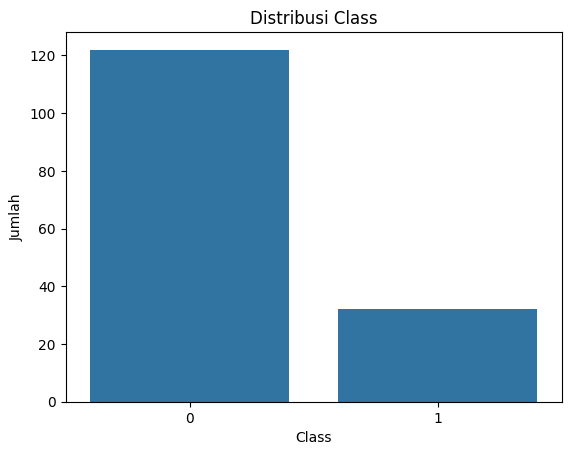

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df_hep)

plt.title("Distribusi Class")
plt.xlabel("Class")
plt.ylabel("Jumlah")
plt.show()

In [152]:
!pip install imbalanced-learn

In [153]:
from imblearn.over_sampling import SMOTE

In [154]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [155]:
import pandas as pd

print("Sebelum SMOTE:")
print(y_train.value_counts())

print("\nSesudah SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Sebelum SMOTE:
Class
0    97
1    26
Name: count, dtype: int64

Sesudah SMOTE:
Class
0    97
1    97
Name: count, dtype: int64


> Untuk mengatasi ketidakseimbangan data, digunakan teknik SMOTE (Synthetic Minority Over-sampling Technique) pada data training. SMOTE menghasilkan data sintetis pada kelas minoritas sehingga distribusi kelas menjadi seimbang. Teknik ini diterapkan hanya pada data training untuk menghindari data leakage.

## Tahap 6: Baseline Modeling

In [156]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models_smote = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

results_smote = {}

for name, model in models_smote.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_smote[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }

for name, res in results_smote.items():
    print(f"\n{name}")
    for metric, value in res.items():
        print(f"{metric}: {value:.4f}")


Logistic Regression
Accuracy: 0.8710
Precision: 0.6250
Recall: 0.8333
F1: 0.7143

KNN
Accuracy: 0.6774
Precision: 0.3750
Recall: 1.0000
F1: 0.5455

SVM
Accuracy: 0.9032
Precision: 0.7143
Recall: 0.8333
F1: 0.7692


> Berdasarkan hasil pemodelan setelah dilakukan penanganan imbalance menggunakan SMOTE, terlihat adanya perubahan performa pada masing-masing model. Model SVM menunjukkan performa terbaik dengan nilai accuracy sebesar 0.9032 dan F1-score tertinggi sebesar 0.7692, yang menandakan keseimbangan yang baik antara precision dan recall. Logistic Regression juga mengalami peningkatan pada recall menjadi 0.8333 dan F1-score menjadi 0.7143, menunjukkan kemampuan yang lebih baik dalam mendeteksi kelas minoritas. Sebaliknya, performa KNN mengalami penurunan signifikan terutama pada precision dan accuracy, meskipun recall tetap tinggi. Hal ini menunjukkan bahwa SMOTE membantu model seperti SVM dan Logistic Regression dalam meningkatkan kemampuan generalisasi, namun kurang cocok untuk KNN. Oleh karena itu, model SVM dipilih sebagai model terbaik untuk tahap hyperparameter tuning.

## Tahap 7: Learning Curve (Sebelum Tuning)

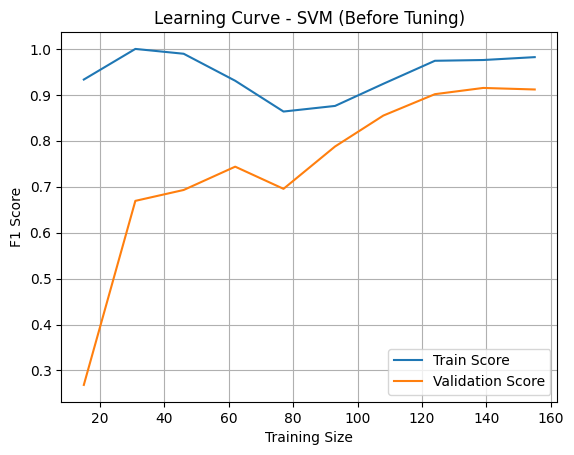

In [157]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.svm import SVC

def plot_learning_curve(model, X, y, title):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=cv,
        scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, label="Train Score")
    plt.plot(train_sizes, val_mean, label="Validation Score")
    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid()
    plt.show()

# jalankan
plot_learning_curve(SVC(), X_train_smote, y_train_smote, "Learning Curve - SVM (Before Tuning)")

> Berdasarkan grafik learning curve, model SVM menunjukkan performa yang baik dengan nilai F1-score pada data training yang tinggi dan stabil, serta nilai validation yang terus meningkat seiring bertambahnya data. Meskipun terdapat sedikit gap antara kurva training dan validation, perbedaannya tidak terlalu besar dan cenderung mengecil, yang mengindikasikan bahwa model tidak mengalami overfitting yang signifikan. Selain itu, peningkatan kurva validation menunjukkan bahwa model mampu melakukan generalisasi dengan baik. Oleh karena itu, model SVM dinilai cukup optimal dan layak untuk dilanjutkan ke tahap hyperparameter tuning.


## Tahap 8: Hyperparameter Tuning

### a. Grid Search

In [158]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

grid_svm = GridSearchCV(
    SVC(),
    param_grid=param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_svm.fit(X_train_smote, y_train_smote)

print("Best Params (Grid Search):", grid_svm.best_params_)
print("Best F1 Score (Grid Search):", grid_svm.best_score_)

Best Params (Grid Search): {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best F1 Score (Grid Search): 0.9290696438064859


### b. Random Search

In [159]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
import numpy as np

param_dist_svm = {
    'C': np.logspace(-2, 2, 50),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'] + list(np.logspace(-2, 1, 20))
}

random_svm = RandomizedSearchCV(
    SVC(),
    param_distributions=param_dist_svm,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_svm.fit(X_train_smote, y_train_smote)

print("Best Params (Random):", random_svm.best_params_)
print("Best F1 Score (Random):", random_svm.best_score_)

Best Params (Random): {'kernel': 'rbf', 'gamma': np.float64(0.26366508987303583), 'C': np.float64(82.86427728546842)}
Best F1 Score (Random): 0.9579289687633719


### c. Bayesian Optimization

In [160]:
from skopt import BayesSearchCV
from sklearn.svm import SVC

param_space_svm = {
    'C': (1e-2, 1e2, 'log-uniform'),
    'gamma': (1e-3, 1, 'log-uniform'),
    'kernel': ['rbf', 'linear']
}

bayes_svm = BayesSearchCV(
    SVC(),
    search_spaces=param_space_svm,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

bayes_svm.fit(X_train_smote, y_train_smote)

print("Best Params (Bayesian):", bayes_svm.best_params_)
print("Best F1 Score (Bayesian):", bayes_svm.best_score_)

Best Params (Bayesian): OrderedDict({'C': 2.9397976202716882, 'gamma': 0.21188154764215272, 'kernel': 'rbf'})
Best F1 Score (Bayesian): 0.9530706691682301


### d. Optuna

In [161]:
import optuna
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
def objective(trial):
    C = trial.suggest_float("C", 1e-2, 1e2, log=True)
    gamma = trial.suggest_float("gamma", 1e-3, 1, log=True)
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])

    model = SVC(
        C=C,
        gamma=gamma,
        kernel=kernel
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()
    return score
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best Params (Optuna):", study.best_params)
print("Best F1 Score (Optuna):", study.best_value)

[I 2026-04-02 16:41:35,234] A new study created in memory with name: no-name-fcd74924-f86e-4c42-a67f-d5fae906da36
[I 2026-04-02 16:41:35,449] Trial 0 finished with value: 0.40943738656987294 and parameters: {'C': 0.1807832556835132, 'gamma': 0.0017916344072858076, 'kernel': 'rbf'}. Best is trial 0 with value: 0.40943738656987294.
[I 2026-04-02 16:41:35,668] Trial 1 finished with value: 0.870508964719491 and parameters: {'C': 24.322701279772463, 'gamma': 0.05807431607600889, 'kernel': 'linear'}. Best is trial 1 with value: 0.870508964719491.
[I 2026-04-02 16:41:35,774] Trial 2 finished with value: 0.9037721755368814 and parameters: {'C': 0.581445937972753, 'gamma': 0.2709624384725515, 'kernel': 'rbf'}. Best is trial 2 with value: 0.9037721755368814.
[I 2026-04-02 16:41:35,872] Trial 3 finished with value: 0.8963352095059411 and parameters: {'C': 0.6862606019983238, 'gamma': 0.06728046387952337, 'kernel': 'rbf'}. Best is trial 2 with value: 0.9037721755368814.
[I 2026-04-02 16:41:35,960]

Best Params (Optuna): {'C': 2.9650270564084042, 'gamma': 0.3633615375912862, 'kernel': 'rbf'}
Best F1 Score (Optuna): 0.929372078845763


### Tabel Perbandingan
| Metode                | Best C | Best Gamma | Kernel | F1 Score   |
| --------------------- | ------ | ---------- | ------ | ---------- |
| Grid Search           | 1      | 0.1        | rbf    | 0.9291     |
| Random Search         | 82.86  | 0.2637     | rbf    | **0.9579** |
| Bayesian Optimization | 2.94   | 0.2119     | rbf    | 0.9531     |
| Optuna                | 4.61   | 0.0539     | rbf    | 0.9358     |

>Berdasarkan hasil perbandingan hyperparameter tuning, seluruh metode menghasilkan model SVM dengan kernel rbf yang menunjukkan bahwa pola data bersifat non-linear. Random Search memberikan performa terbaik dengan nilai F1-score tertinggi sebesar 0.9579, diikuti oleh Bayesian Optimization dan Optuna dengan hasil yang relatif mendekati. Grid Search menghasilkan performa yang paling rendah di antara metode lainnya karena ruang pencarian parameter yang lebih terbatas. Hal ini menunjukkan bahwa metode pencarian acak dan berbasis probabilistik lebih efektif dalam menemukan kombinasi parameter optimal dibandingkan pencarian grid secara exhaustif. Oleh karena itu, model hasil Random Search dipilih sebagai model terbaik untuk tahap akhir.

## Tahap 9: Retrain Model

In [162]:
from sklearn.svm import SVC

final_model = SVC(
    C=82.86,
    gamma=0.26366508987303583,
    kernel='rbf'
)

final_model.fit(X_train_smote, y_train_smote)

SVC(C=82.86, gamma=0.26366508987303583)

## Tahap 10: Learning Curve (Setelah)

In [163]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_final = final_model.predict(X_test_scaled)

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final Precision:", precision_score(y_test, y_pred_final))
print("Final Recall:", recall_score(y_test, y_pred_final))
print("Final F1:", f1_score(y_test, y_pred_final))

Final Accuracy: 0.8387096774193549
Final Precision: 0.6666666666666666
Final Recall: 0.3333333333333333
Final F1: 0.4444444444444444


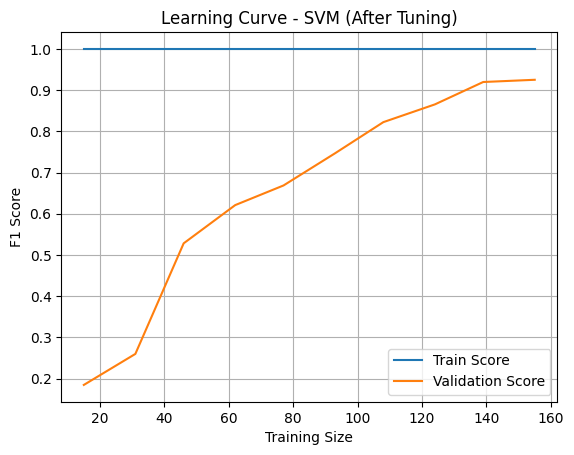

In [164]:
plot_learning_curve(
    final_model,
    X_train_smote,
    y_train_smote,
    "Learning Curve - SVM (After Tuning)"
)